In [3]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 1

%aimport b6_epilepsies 
import b6_epilepsies as b6 #.py file in the same dir as this .ipynb
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# sns.set_theme(style="whitegrid", context="notebook", palette="muted")

# Define the custom color palette and genotype order
# new_colors_order = sns.color_palette(palette='Set2', n_colors=3)
# new_colors_order[0], new_colors_order[1], new_colors_order[2] = new_colors_order[1], new_colors_order[0], new_colors_order[2]
# color_map = dict(zip(['wt', 'het', 'hom'], new_colors_order))

# Define input variables
date   = "250214"
box1   = "14"
box2   = "15"
exp    = "ALDH7A1_20LYS_7dpf"
export = False

omit = {box1:['H7','D8','D9','D12']}
    
ald_lys_obj_raw = b6.RawData(date, box1, box2, exp, export) #.prepped_data attribute to access df

# ald_lys_obj_mid  = b6.MiddurData(date, box1, box2, exp, export, omit=omit) #.prepped_data attribute to access df
df_raw = ald_lys_obj_raw.df

Initialising RawData...
Start of experiment: 2025-02-14 10:07:08
Instantiated using 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_processed.csv, no need to prepare raw data.
Done.


In [296]:
# very_raw_df = pd.read_csv('250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_raw_df.csv')
# len(very_raw_df[(very_raw_df['type']==101) & (very_raw_df['location']=='C026')])
# very_raw_df[(very_raw_df['type']==101) & (very_raw_df['location']=='C026')]


,abstime,time,channel,type,location,data1
320,142847552,27045,0,101,C026,0.0
505,142879523,59016,0,101,C026,0.0
695,142918159,97652,0,101,C026,0.0
888,143001339,180832,0,101,C026,51.0
985,143038397,217890,0,101,C026,65.0
...,...,...,...,...,...,...
54759096,11867070697,11724250190,0,101,C026,0.0
54759220,11867117627,11724297120,0,101,C026,0.0
54759385,11867161402,11724340895,0,101,C026,0.0
54759507,11867197832,11724377325,0,101,C026,0.0


/var/folders/99/9p1rqw911_b36bj9w7ly35q80000gn/T/ipykernel_7235/4237994958.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_smoothed = df.groupby(["box", "well"], group_keys=False).apply(smooth_group, sigma=sigma_value)


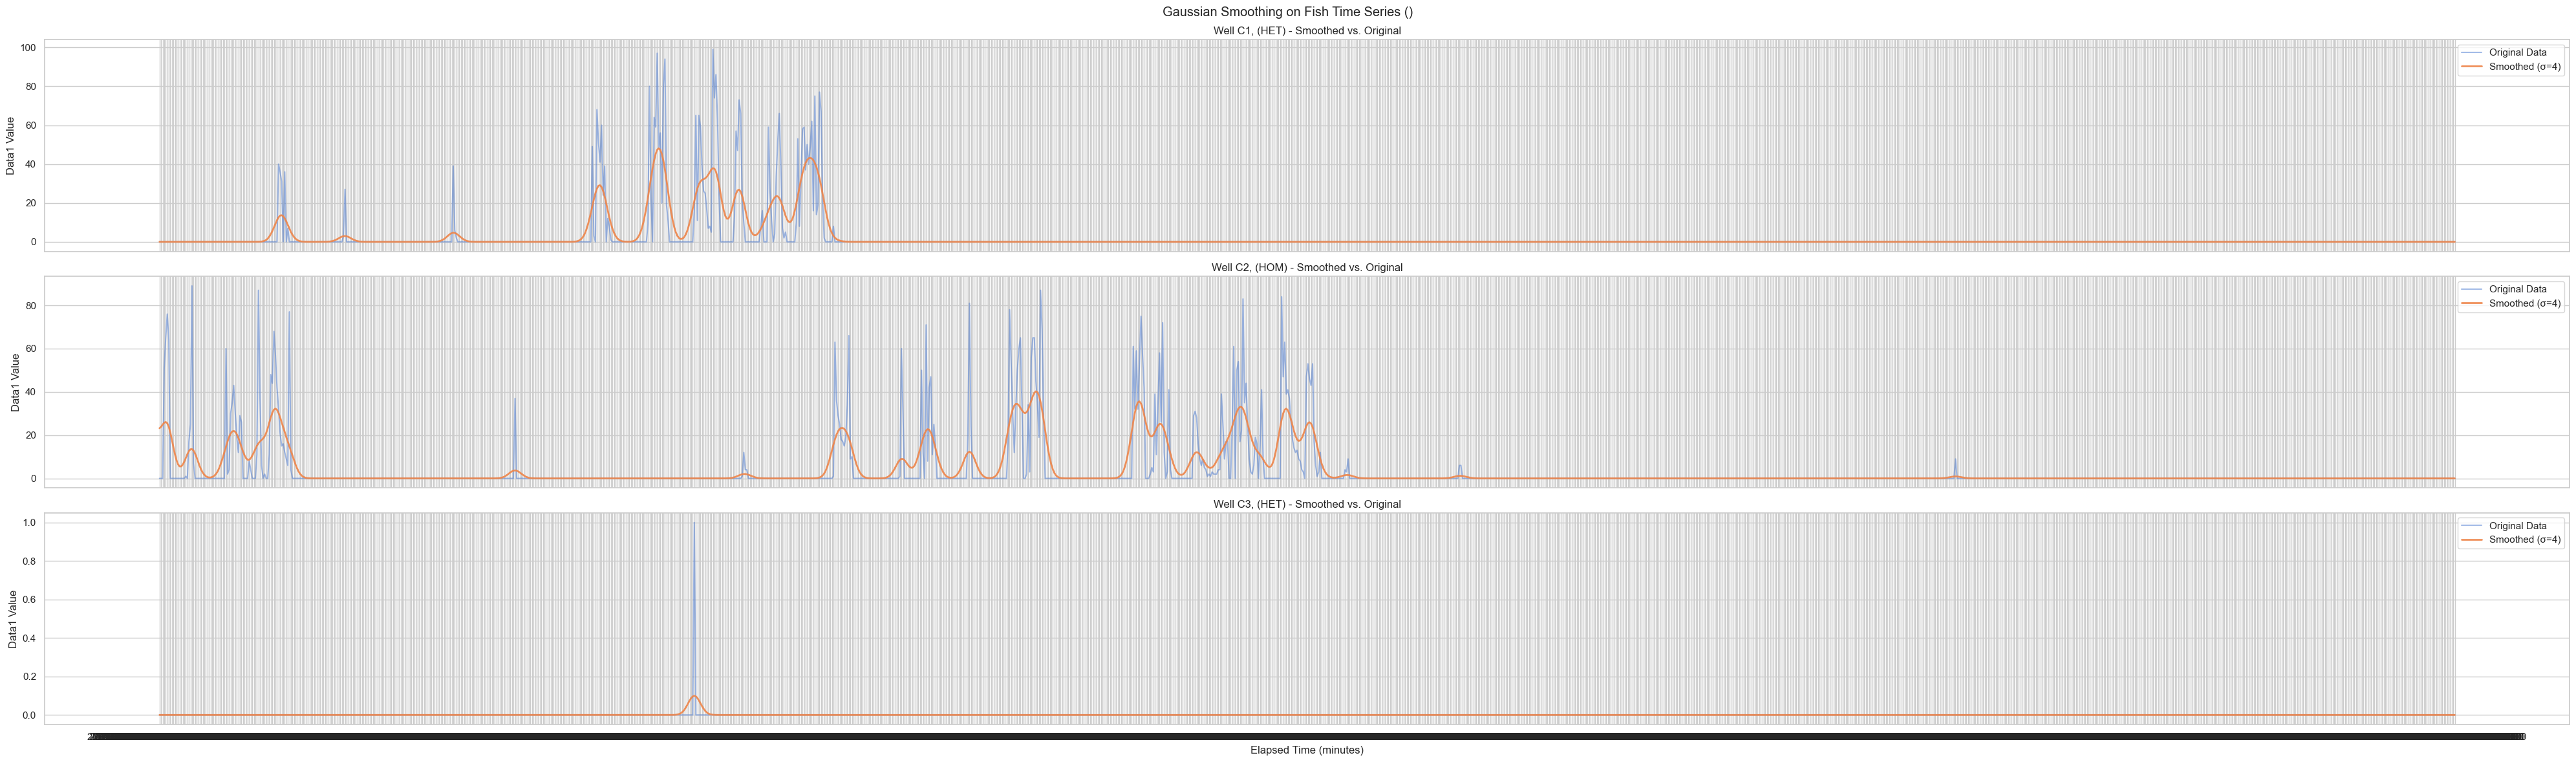

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
sns.set_theme(style=None, context="notebook", palette="muted")


df = df_raw

# Convert elapsed_time to numeric (if needed)
df["elapsed_time"] = pd.to_numeric(df["elapsed_time"], errors="coerce")

# Function to apply Gaussian smoothing per fish (grouped by box and well)
def smooth_group(group, sigma=5):
    group = group.sort_values(by="elapsed_time")  # Ensure chronological order
    group["smoothed_data1"] = gaussian_filter1d(group["data1"], sigma=sigma)  # Apply smoothing
    return group

# Apply smoothing to each fish individually
sigma_value = 4  # Adjust smoothing level
df_smoothed = df.groupby(["box", "well"], group_keys=False).apply(smooth_group, sigma=sigma_value)

# **Filter by time elapsed in minutes**
df_smoothed_10min = df_smoothed[df_smoothed["elapsed_time"] <= 1]  # Now correctly using minutes

# **Select a few example wells to plot separately**
example_wells = df_smoothed_10min["well"].unique()[24:27]  # Pick first 3 wells
# example_wells = df_smoothed_10min["well"].unique()[24:28]  # Pick first 3 wells
num_wells = len(example_wells)

# Set up separate subplots for each well
fig, axes = plt.subplots(num_wells, 1, figsize=(40, 4 * num_wells), sharex=True)

if num_wells == 1:  # Ensure `axes` is iterable even if there's only one plot
    axes = [axes]

for ax, well in zip(axes, example_wells):
    well_data = df_smoothed_10min[df_smoothed_10min["well"] == well]
    genotype  = well_data['genotype'].unique()[0]
    ax.plot(well_data["fullts"], well_data["data1"], alpha=0.5, linestyle="solid", label="Original Data")
    ax.plot(well_data["fullts"], well_data["smoothed_data1"], label=f"Smoothed (σ={sigma_value})", linewidth=2, alpha=0.9)
    ax.set_title(f"Well {well}, ({genotype}) - Smoothed vs. Original")
    ax.set_ylabel("Data1 Value")
    ax.legend()

# Set common x-label
plt.xlabel("Elapsed Time (minutes)")
plt.suptitle("Gaussian Smoothing on Fish Time Series ()")
plt.tight_layout()
plt.show()

In [21]:
df_smoothed[df_smoothed['well']=='A2']

,fullts,elapsed_time,box,well,genotype,data1,smoothed_data1
1,2025-02-14 10:07:08.027045000,0.000000,14,A2,HOM,0.0,25.870186
64,2025-02-14 10:07:08.059016000,0.000533,14,A2,HOM,0.0,26.380693
127,2025-02-14 10:07:08.097652000,0.001177,14,A2,HOM,38.0,27.336302
190,2025-02-14 10:07:08.180832000,0.002563,14,A2,HOM,30.0,28.613499
253,2025-02-14 10:07:08.217890000,0.003181,14,A2,HOM,54.0,30.045716
...,...,...,...,...,...,...,...
18415657,2025-02-14 13:22:32.250190000,195.403719,14,A2,HOM,0.0,0.000000
18415720,2025-02-14 13:22:32.297120000,195.404501,14,A2,HOM,0.0,0.000000
18415783,2025-02-14 13:22:32.340895000,195.405231,14,A2,HOM,0.0,0.000000
18415846,2025-02-14 13:22:32.377325000,195.405838,14,A2,HOM,0.0,0.000000


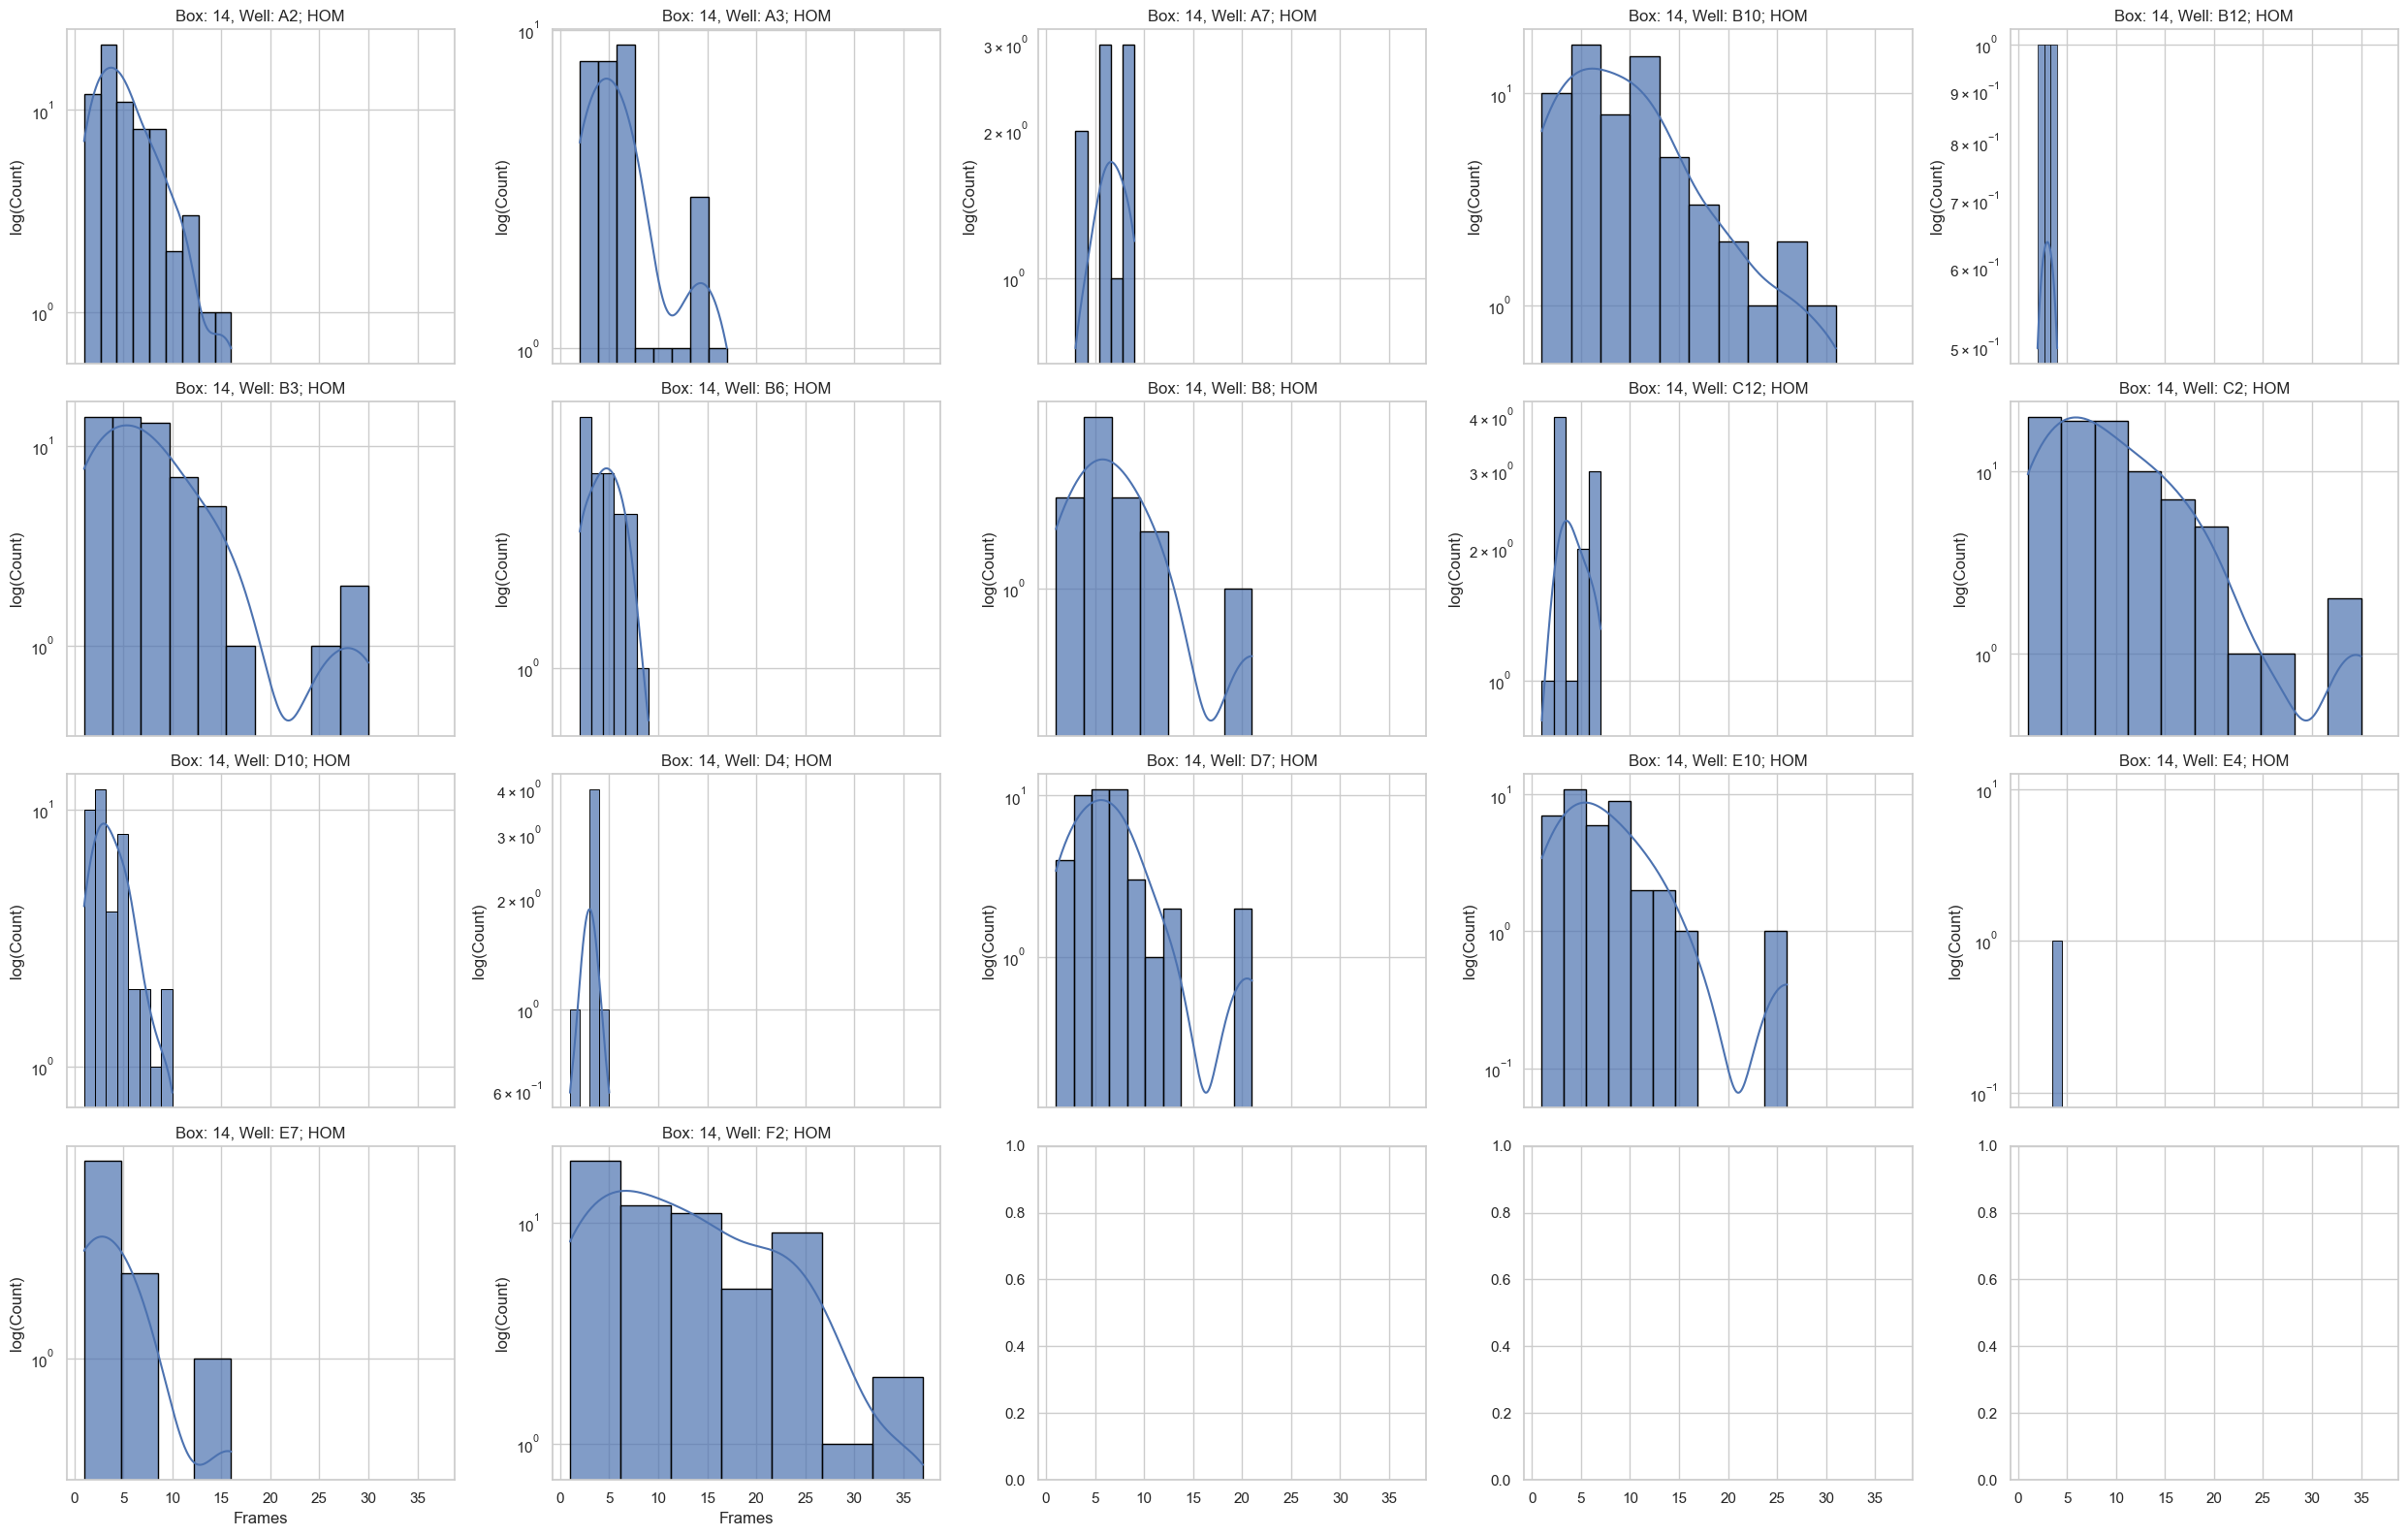

In [39]:
all_homs = df_raw[df_raw["genotype"] == "HOM"]
all_homs_grouped = list(all_homs.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_homs_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list, full_df=df_smoothed, col='smoothed_data1')

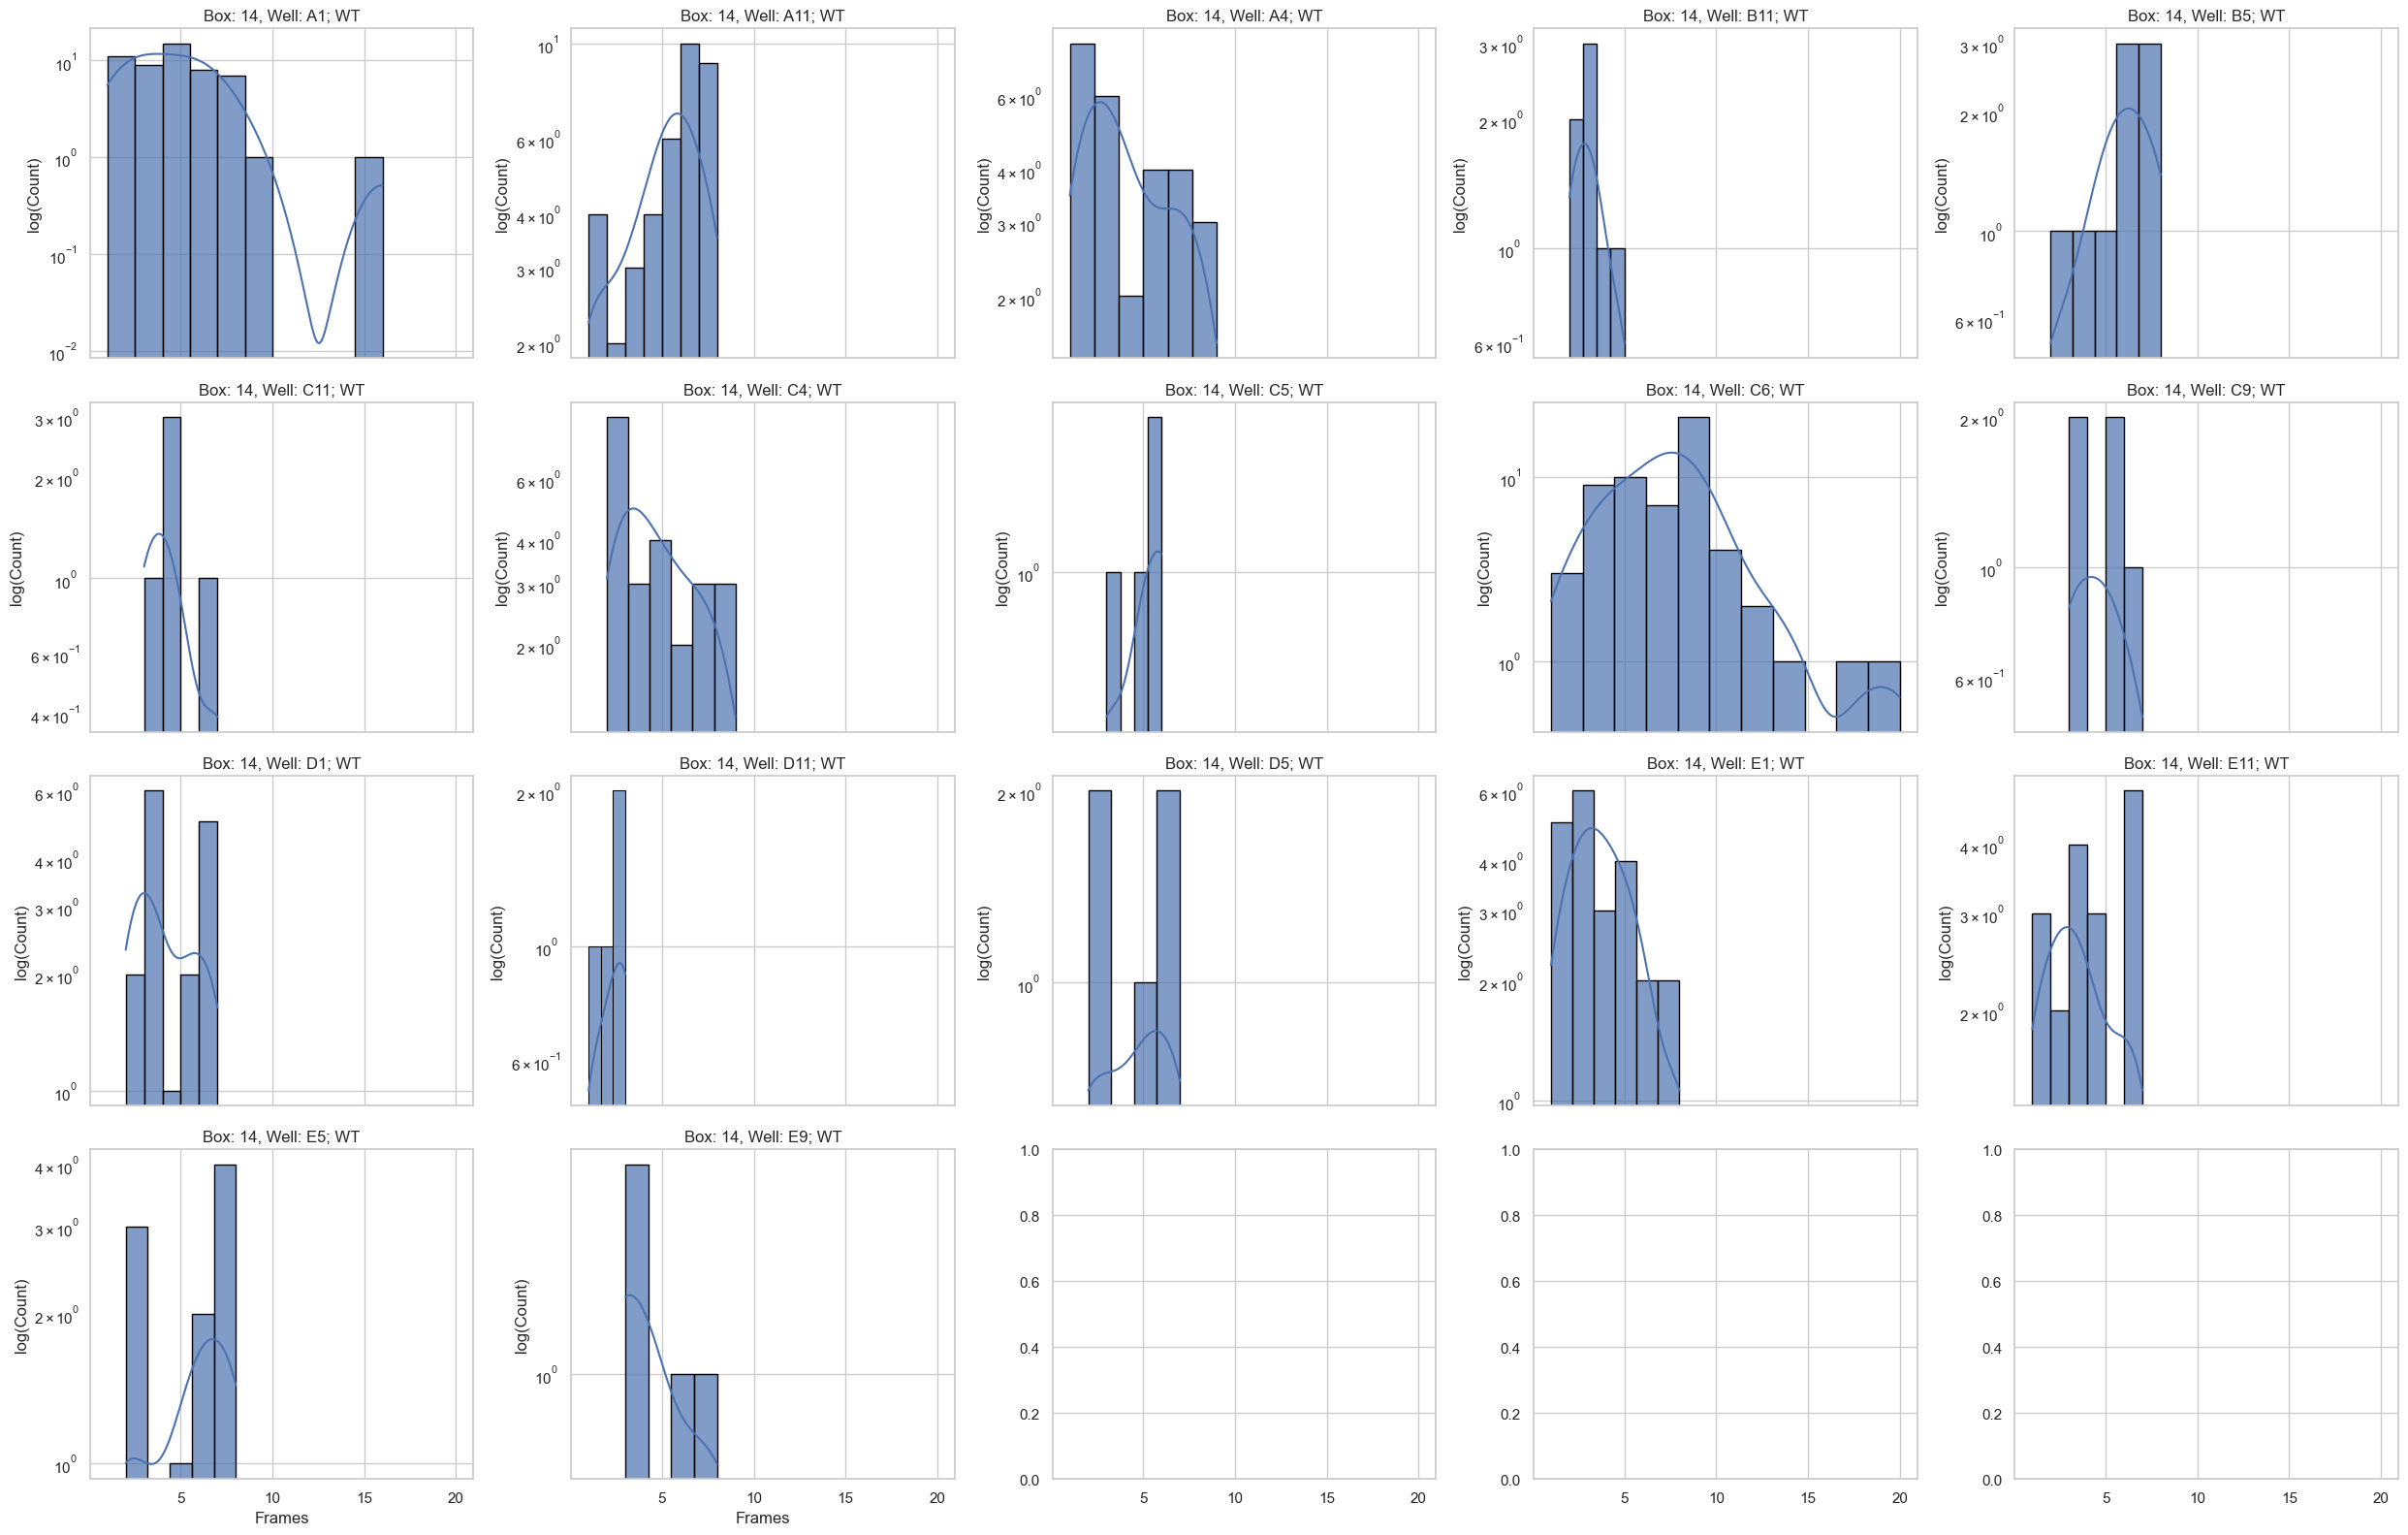

In [40]:
all_wts = df_raw[df_raw["genotype"] == "WT"]
all_wts_grouped = list(all_wts.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_wts_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list, full_df=df_smoothed, col='smoothed_data1')


In [ ]:



fishC2        = df_raw[df_raw['well'] == 'C2'] #HOM

# Define threshold
threshold = 40

# Ensure data is sorted by time
df = fishC2.sort_values(by="fullts")

# Create a boolean column indicating if data1 is above the threshold
df["above_threshold"] = df["data1"] >= threshold

# Initialize variables
frame_count = 0
count_durations = []  # List to store number of frames in each threshold exceedance
above_threshold = False  # Track whether we're in a threshold-exceeding period

# Iterate through dataframe using .itertuples() (more efficient)
for row in df.itertuples(index=False):
    if row.above_threshold:
        if not above_threshold:  # First frame crossing threshold
            frame_count = 1  # Start counting
            above_threshold = True
        else:
            frame_count += 1  # Keep counting frames
    else:
        if above_threshold:  # Just dropped below threshold
            count_durations.append(frame_count)  # Store frame count
            above_threshold = False
            frame_count = 0  # Reset counter

# If the last value was still above the threshold, store the final count
if above_threshold:
    count_durations.append(frame_count)

# Output the frame count durations
print(f"Frame counts where data1 exceeded the threshold ({start}, {end}):", count_durations)
# fishA1_count_durations = count_durations
# ax = sns.histplot(fishA1_count_durations, kde=True, edgecolor="black", alpha=0.7)
# ax.set_yscale("log")

In [ ]:
# Filter for the specific well
fishC2 = df_raw[df_raw['well'] == 'C2']  # HOM

# Define thresholds
threshold = 40  # Activity level for potential seizure
lower_bound = 5  # Defines "zero" or near-zero baseline
min_duration = 8  # Minimum frames required to qualify as a seizure event
min_ibi = 8  # Minimum interbout interval to confirm a separate event

# Ensure data is sorted by time
df = fishC2.sort_values(by="fullts").reset_index(drop=True)

# Create a boolean column indicating if data1 is above the threshold
df["above_threshold"] = df["data1"] >= threshold

# Initialize variables
seizure_events = []  # Stores (start_frame, end_frame, duration, IBI)
in_seizure = False  # Flag to track if we're currently in a seizure
start_frame = None  # To store the start of the bout
end_frame = None  # To store the end of the bout
last_end_frame = None  # Tracks the last confirmed event's end

# Iterate over DataFrame rows
for i, row in df.iterrows():
    if row["above_threshold"]:
        if not in_seizure:  # First frame crossing threshold
            # Look backward to find the start of the bout
            for j in range(i, -1, -1):
                if df.loc[j, "data1"] <= lower_bound:  # Find last zero (or close)
                    start_frame = j
                    break
            in_seizure = True  # Mark that we're in a seizure
    else:
        if in_seizure:  # Just dropped below threshold
            # Look forward to confirm the actual end
            for j in range(i, len(df)):
                if df.loc[j, "data1"] <= lower_bound:  # Ensure we reached baseline
                    end_frame = j
                    break
            duration = end_frame - start_frame

            if duration > min_duration:  # Only register if duration > 8 frames
                if last_end_frame is not None:
                    ibi = start_frame - last_end_frame  # Interbout interval
                else:
                    ibi = None  # No previous event to compare
                
                # Merge with the last event if IBI is too short
                if ibi is not None and ibi <= min_ibi:
                    # Extend the last event instead of creating a new one
                    last_event = seizure_events.pop()
                    new_event = (last_event[0], end_frame, end_frame - last_event[0], last_event[3])
                    seizure_events.append(new_event)
                else:
                    # Store as a new seizure event
                    seizure_events.append((start_frame, end_frame, duration, ibi))

                last_end_frame = end_frame  # Update last end frame
            in_seizure = False  # Reset flag
            start_frame = None
            end_frame = None

# If the last detected bout is still active at the end, close it
if in_seizure:
    duration = len(df) - 1 - start_frame
    if duration > min_duration:
        ibi = start_frame - last_end_frame if last_end_frame is not None else None
        seizure_events.append((start_frame, len(df) - 1, duration, ibi))

# Output detected seizure events with IBI
for event in seizure_events:
    print(f"Seizure from frame {event[0]} to {event[1]} (Duration: {event[2]} frames, IBI: {event[3]} frames)")

Number of Seizure Events detected: 16 (D6, HET)


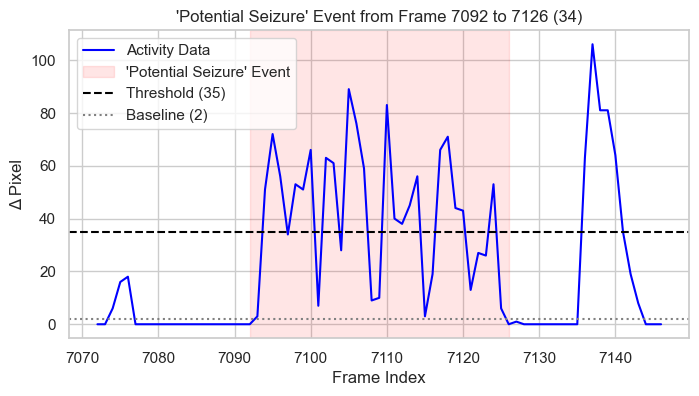

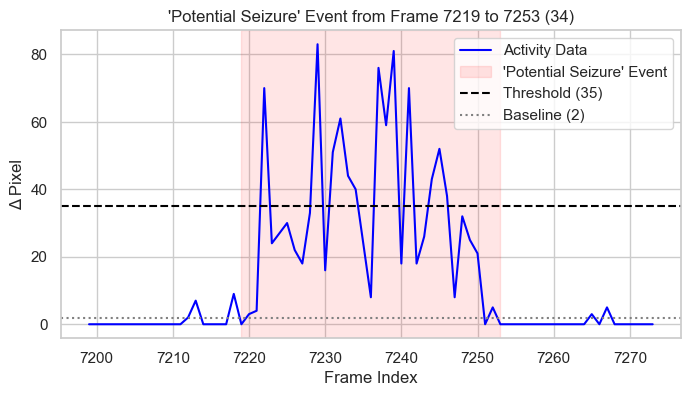

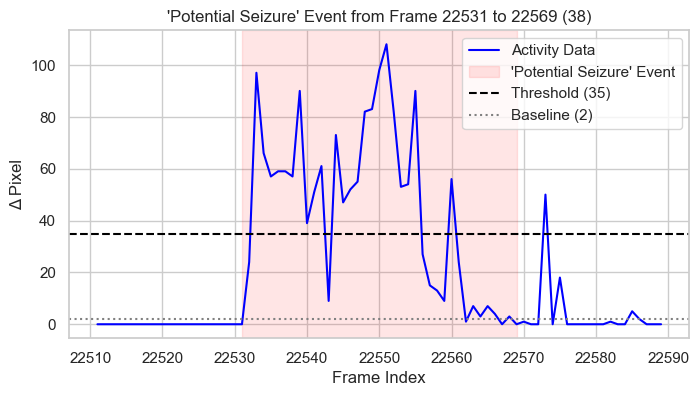

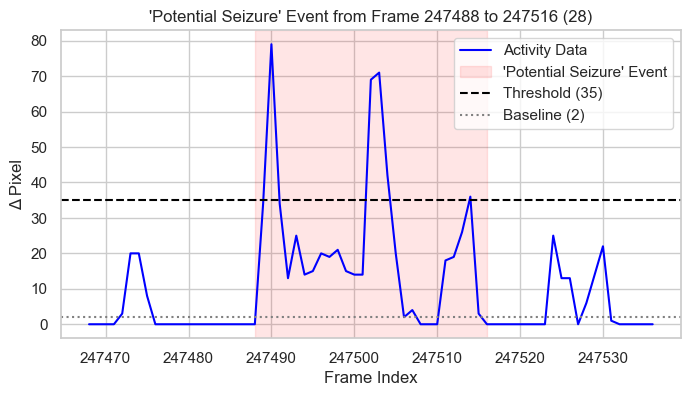

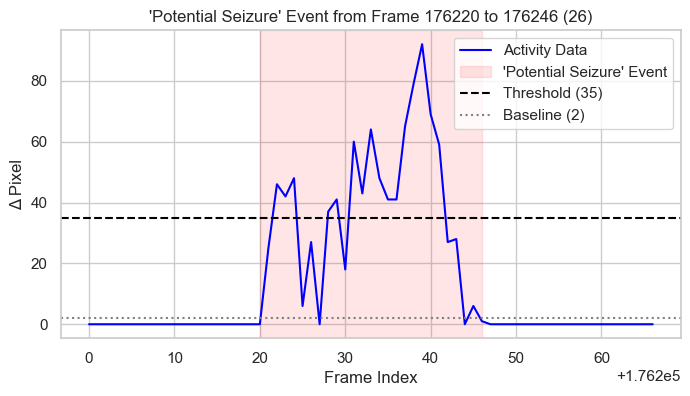

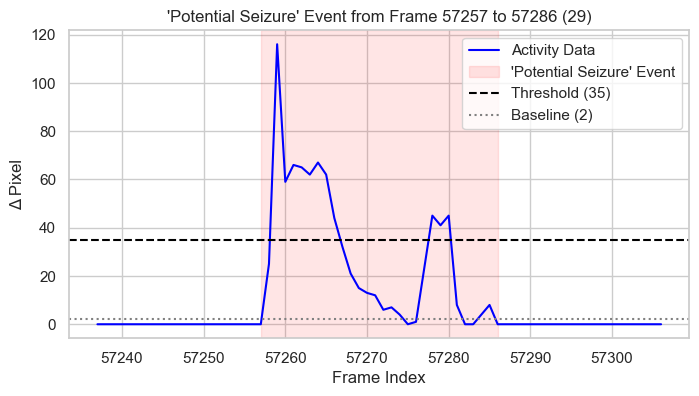

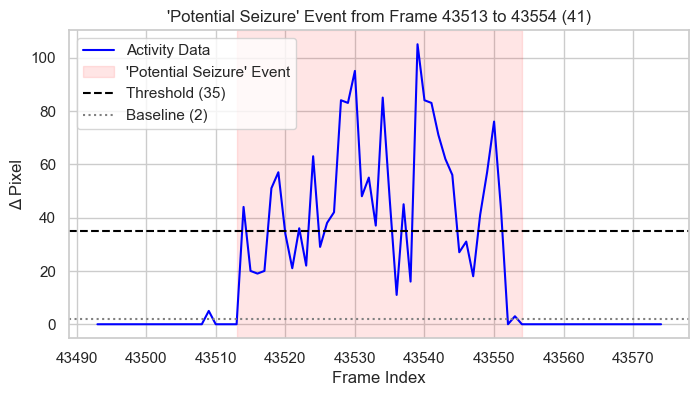

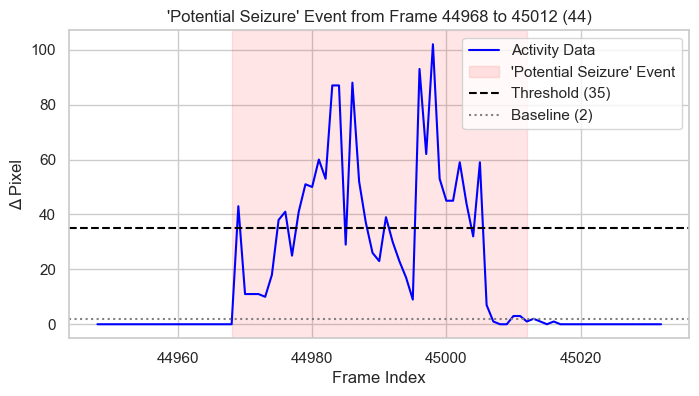

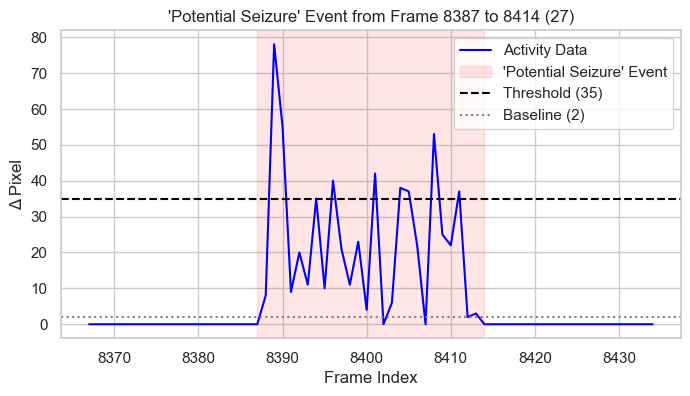

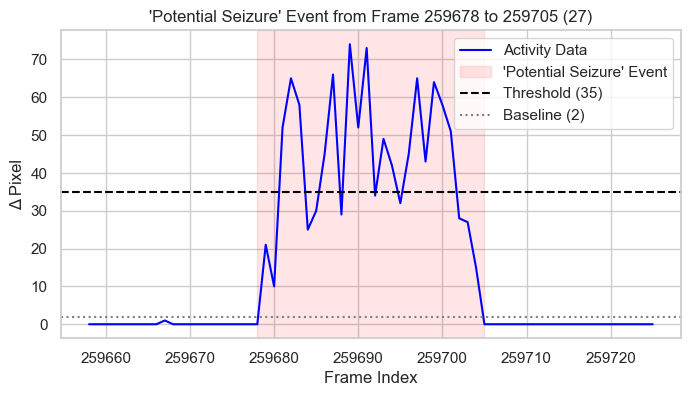

In [289]:
fishD6 = df_raw[df_raw['well'] == 'D6'].copy()  # HET
seizure_df_D6 = detect_seizures_and_plot(fishD6)

In [276]:
fishC3 = df_raw[df_raw['well'] == 'C3'].copy()  # HET
seizure_df_C3 = detect_seizures_and_plot(fishC3)

Number of Seizure Events detected: 0


Number of Seizure Events detected: 3


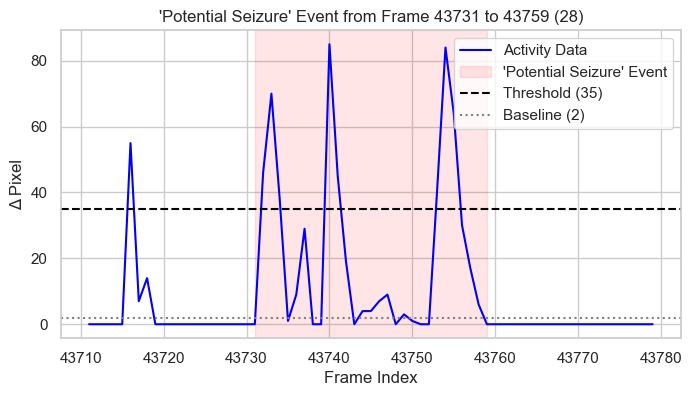

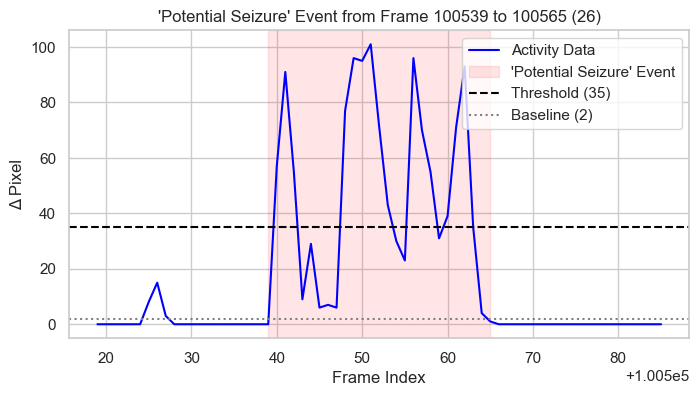

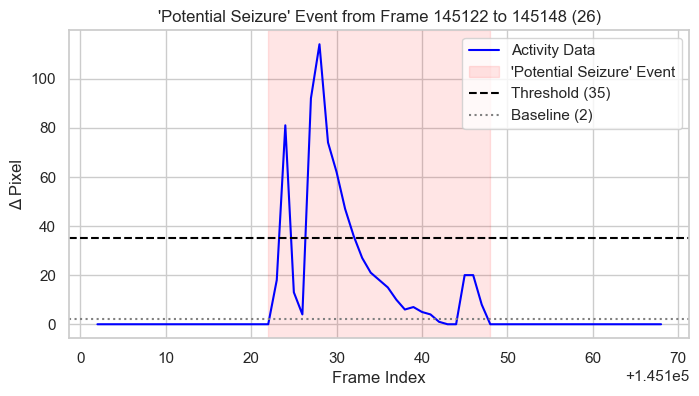

In [52]:
fishA1 = df_raw[df_raw['well'] == 'A1'].copy()  # HOM
seizure_df_A1 = detect_seizures_and_plot(fishA1)

292317

Number of Seizure Events detected: 90 (C2, HOM)


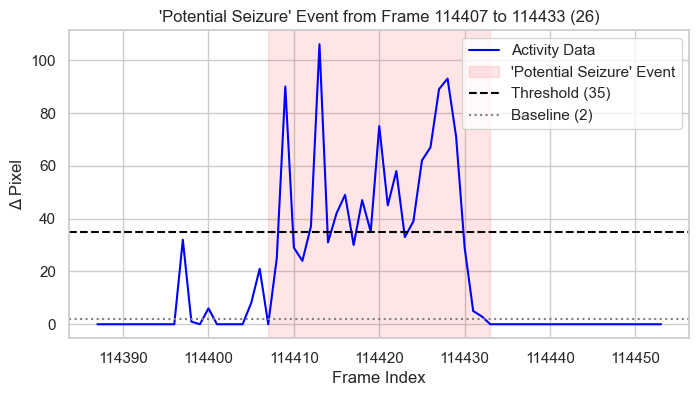

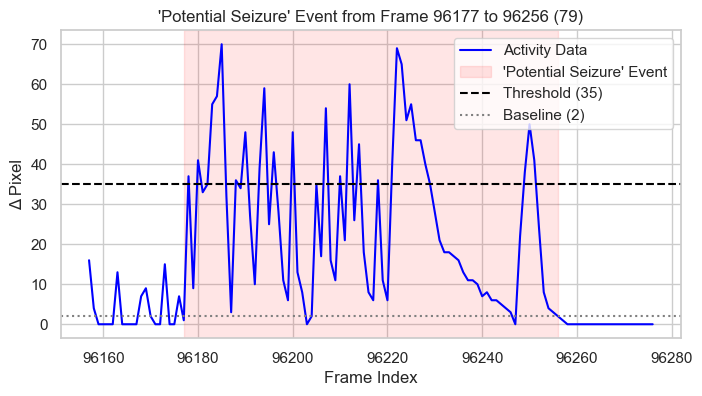

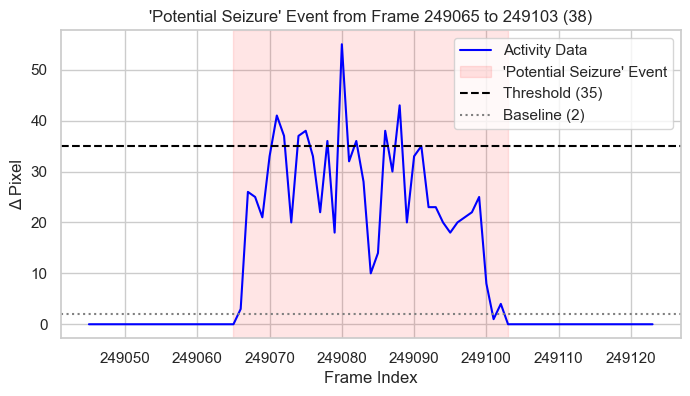

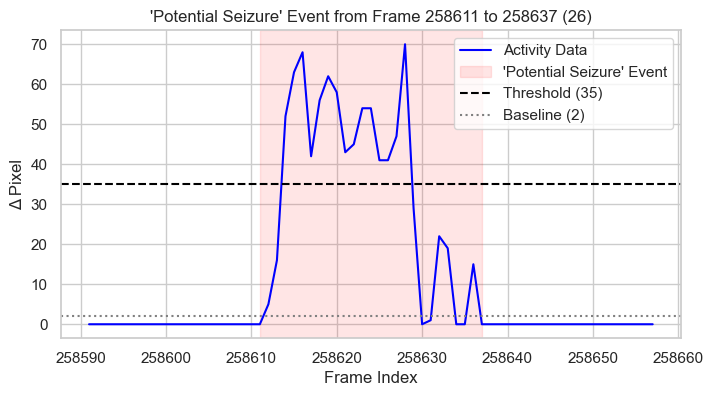

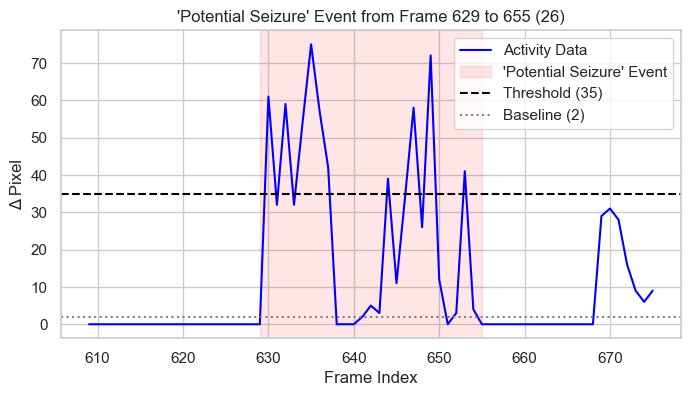

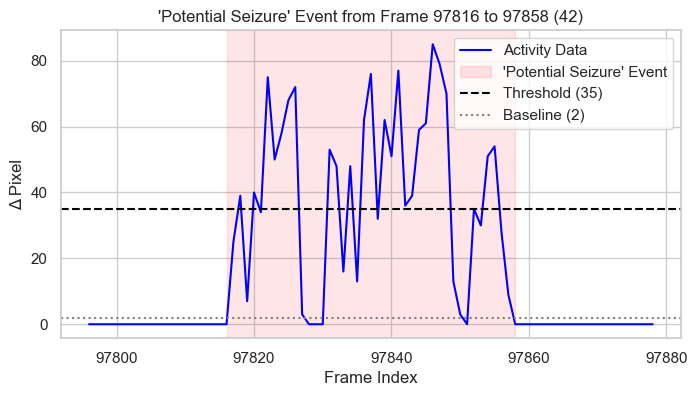

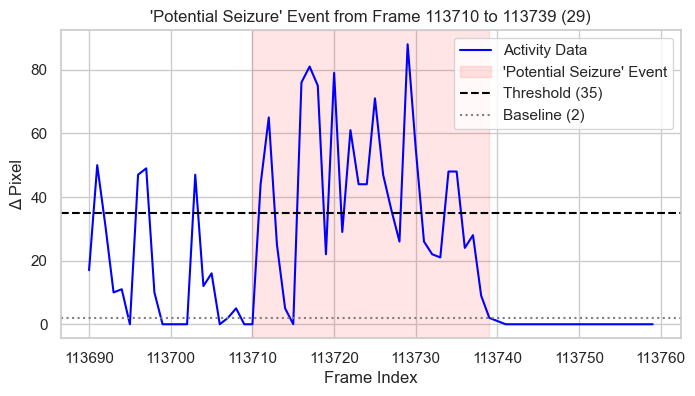

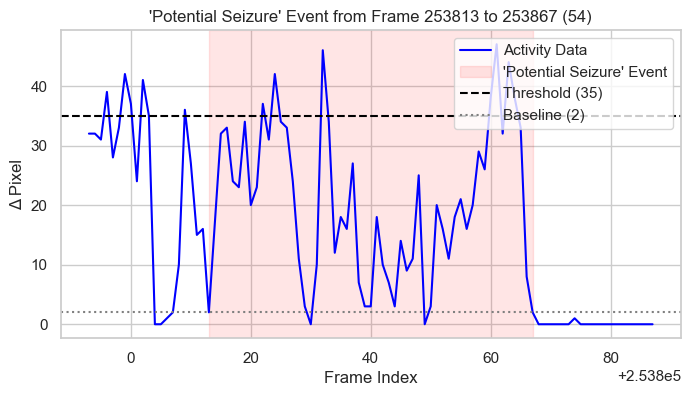

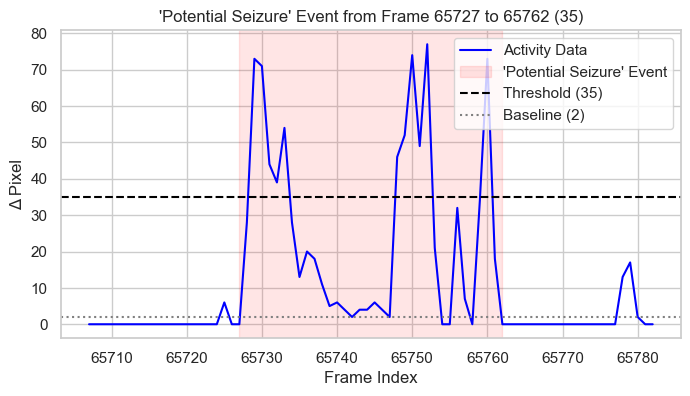

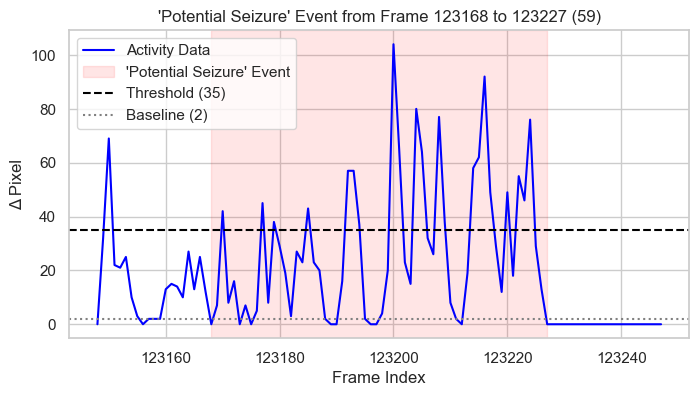

In [312]:
fishC2 = df_raw[df_raw['well'] == 'C2'].copy()  # HOM
seizure_df_C2 = ald_lys_obj_raw.detect_seizures(fishC2, plot=True)
# seizure_df_C2 = detect_seizures_and_plot(fishC2)


In [288]:
def detect_seizures_and_plot(fish):
    # Define thresholds
    upper_threshold    = 35  # Activity level for potential seizure
    lower_threshold    = 2  # Defines "zero" or near-zero baseline
    min_frame_duration = 25  # Minimum frames required to qualify as a seizure event
    min_ibi            = 3  # Minimum interbout interval to confirm a separate event

    # Ensure data is sorted by time (but maintain original index)
    fish = fish.sort_values(by="fullts", ignore_index=True)
    
    # Create a boolean column indicating if data1 is above the threshold
    fish["above_threshold"] = fish["data1"] >= upper_threshold
    fish["below_threshold"] = fish["data1"] <= lower_threshold
    
    # Initialize variables
    seizure_events = []  # Stores (start_index, end_index, duration, IBI)
    temp_events    = []
    in_seizure     = False  # Flag to track if we're currently in a seizure
    start_index    = None  # To store the start of the bout
    end_index      = None  # To store the end of the bout
    
    next_start_index = None  # Tracks the next event's start
    
    potential_event_end = None
    frame_count = 0
    
    # Convert DataFrame index to a list to ensure correct referencing
    frame_indices = fish.index.tolist()
    
    # Detect seizure events
    
    for i, row in fish.iterrows():
        # print(i)
        if row["above_threshold"]:
            # print(f"^ this one is above threshold ({upper_threshold})")
            if not in_seizure:
                for j in range(i, -1, -1): # Look backward for bout start
                    if fish.loc[j, 'below_threshold']:
                        start_index = j
                        # print("START: index=",start_index, "elapsed_time=",fishC2.loc[start_index, 'elapsed_time'])
                        break
                in_seizure  = True
                frame_count = 0
                
        else: # if row is not above upper threshold
            if in_seizure: # but still in seizure and data1 is below the lower threshold
    
                
                if row["below_threshold"]:
                    # print(f"This is below the lower bound ({lower_threshold})")
                    if potential_event_end == None:
                        potential_event_end = i
                    else:
                        frame_count += 1
                    # print(f"This is a potential end; {frame_count}")
                else:
                    # print('Above lower threshold count:',frame_count)
                    if frame_count <= min_ibi: # This means that the event is still ongoing
                        # duration  = potential_event_end - start_index
                        potential_event_end = frame_count
                        temp_event = (start_index, potential_event_end, frame_count, i)
                        temp_events.append(temp_event)
                        # print(f"temp_event: {temp_event}")
                        frame_count = 0
                        
                    elif len(temp_events)>0:
                        # print(f"temp_events: {temp_events}")
                        last_temp_event = temp_events.pop()
                        
                        end_index = last_temp_event[3]+1
                        duration  = end_index - start_index
                        ibi       = (i-1) - end_index
                        # print(i)
                        event     = (start_index, end_index, duration, ibi)
                        if duration > min_frame_duration:
                            seizure_events.append(event)
                        temp_events     = []
    
                    
                    else:
                        
                        
                        end_index = potential_event_end
                        ibi       = frame_count
                        duration  = end_index - start_index
                        # print(temp_events)
                        
                        if duration > min_frame_duration:
                            seizure_events.append((start_index, end_index, duration, ibi))
                            # print(f'START: {start_index}, END: {end_index}, ibi: {ibi}')
                            start_index = end_index + ibi
                            
                        in_seizure = False
                        end_index = None
                        potential_event_end = None  # Reset temporary marker
                        frame_count = 0
                        # temp_events = []
    
    
    # if in_seizure:
    #     duration = len(fishC2) - start_index
    #     if duration > min_frame_duration:
    #         ibi = start_index - last_end_index if last_end_index is not None else None
    #         seizure_events.append((start_index, len(fishC2) - 1, duration, ibi))
            
                
        # if i == 300: break
    
    # Convert seizure events to DataFrame
    seizure_df = pd.DataFrame(seizure_events, columns=["start", "end", "duration", "IBI"])
    
    # Select 5 random seizure events (if available)
    num_events_to_plot = min(10, len(seizure_df))
    selected_events = seizure_df.sample(n=num_events_to_plot, random_state=42)
    # selected_events = seizure_df.loc[:10]
    print(f"Number of Seizure Events detected: {len(seizure_df)} ({fish['well'][0]}, {fish['genotype'][0]})")
    
    # Plot selected seizure events
    for _, event in selected_events.iterrows():
        start, end = event["start"], event["end"]
        
        # Extend the window by 5 frames before and after the event
        start_idx = max(frame_indices.index(start) - 20, 0)
        end_idx = min(frame_indices.index(end) + 20, len(frame_indices) - 1)
        
        # Get the actual frame indices
        # plot_start = frame_indices[start_idx]
        # plot_end = frame_indices[end_idx]
        plot_start = start_idx
        plot_end = end_idx
        
        # Extract subset of data for plotting
        subset = fish.loc[plot_start:plot_end]
    
        # Plot the selected event window
        plt.figure(figsize=(8, 4))
        plt.plot(subset.index, subset["data1"], color="blue", label="Activity Data")
        plt.axvspan(start, end, color="red", alpha=0.1, label="'Potential Seizure' Event")
        
        # Formatting
        plt.axhline(y=upper_threshold, color='black', linestyle='--', label=f"Threshold ({upper_threshold})")
        plt.axhline(y=lower_threshold, color='gray', linestyle=':', label=f"Baseline ({lower_threshold})")
        plt.xlabel("Frame Index")
        plt.ylabel("Δ Pixel")
        plt.title(f"'Potential Seizure' Event from Frame {start} to {end} ({event['duration']})")
        plt.legend()
        plt.show()

    return seizure_df

<AxesSubplot:xlabel='duration', ylabel='Count'>

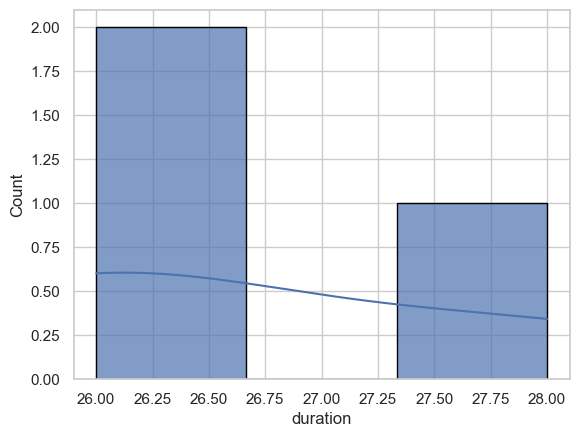

In [53]:
sns.histplot(seizure_df_A1['duration'], kde=True, edgecolor="black", alpha=0.7)

Number of Seizure Events detected: 5


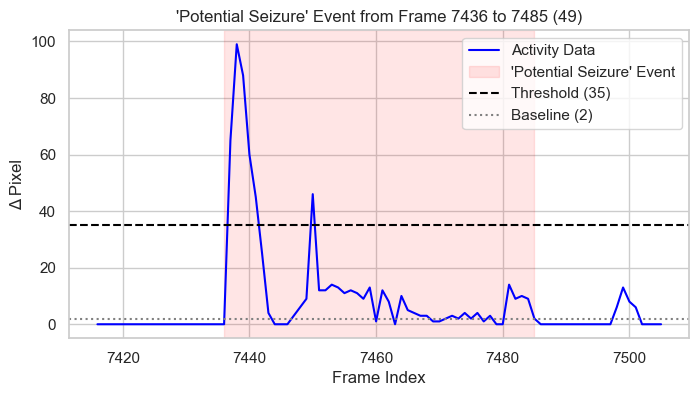

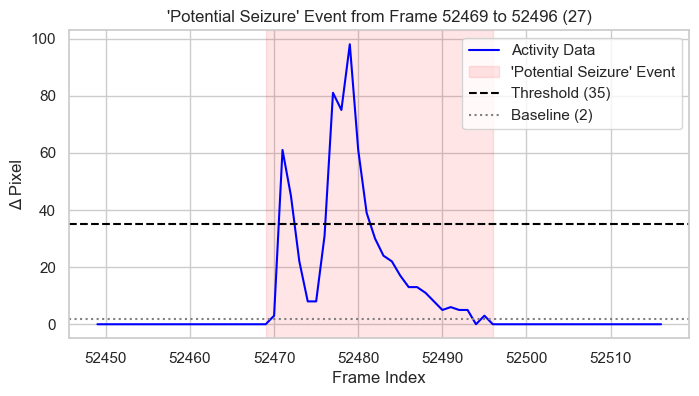

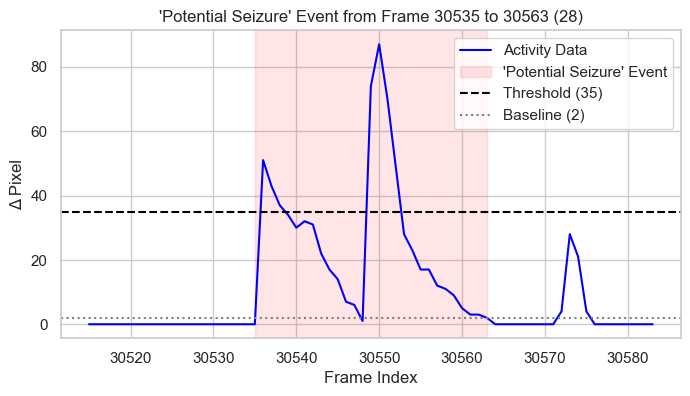

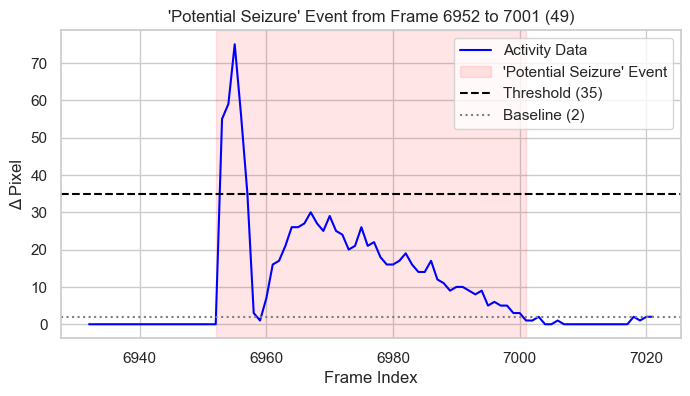

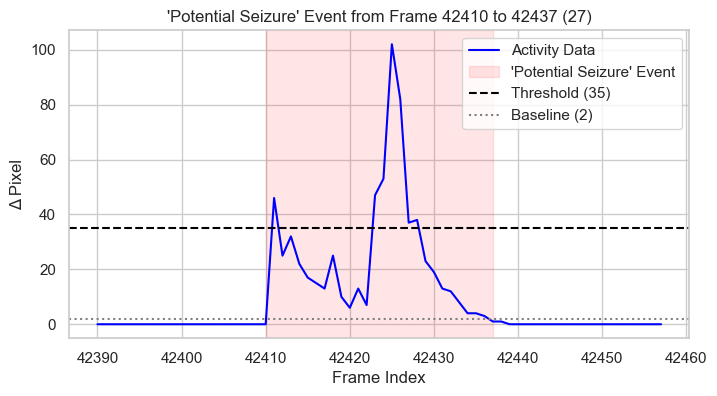

In [54]:
fishC5 = df_raw[df_raw['well'] == 'C5'].copy()  # WT
seizure_df_C5 = detect_seizures_and_plot(fishC5)

<AxesSubplot:xlabel='duration', ylabel='Count'>

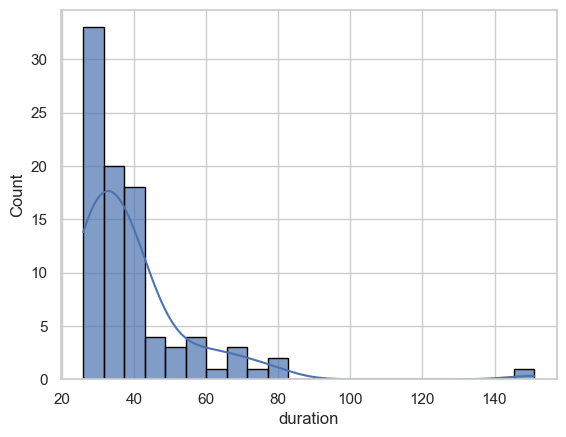

In [55]:
sns.histplot(seizure_df_C2['duration'], kde=True, edgecolor="black", alpha=0.7)

In [23]:
import cv2
import pandas as pd

# Load the event data (replace this with your actual DataFrame)
df = seizure_df_C2
# df = pd.DataFrame(data)

# Load the video
# video_path = "250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_frame.m4v"  # Change to your video file path
video_path = "output_fixed.mp4"
output_path = "output_video.mp4"  # Name of the output file

# Open video capture
cap = cv2.VideoCapture(video_path)
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Define the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

frame_number = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Add frame number to the top-left corner
    cv2.putText(frame, f"Frame: {frame_number}", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    # Check if the current frame falls within an event
    for _, row in df.iterrows():
        if row["start"] <= frame_number <= row["end"]:
            # Draw a red circle and text to indicate an event
            cv2.circle(frame, (50, 50), 20, (0, 0, 255), -1)  # Red circle
            cv2.putText(frame, "EVENT", (80, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # Write the frame to the output video
    out.write(frame)
    
    frame_number += 1

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Processed video saved as {output_path}")

Processed video saved as output_video.mp4


In [287]:
import pandas as pd

# Dictionary to store seizure data for each fish
seizure_data = []

# Loop through each unique fish (well) in df_raw
for well in df_raw['well'].unique():
    fish_data = df_raw[df_raw['well'] == well].copy()
    seizure_df = detect_seizures_and_plot(fish_data)

    # Add well and genotype info to seizure dataframe
    seizure_df['well'] = well
    seizure_df['genotype'] = fish_data['genotype'].iloc[0]  # Assume genotype is constant for a fish

    # Store in list
    seizure_data.append(seizure_df)

# Combine all seizure event data into a single DataFrame
all_seizure_df = pd.concat(seizure_data, ignore_index=True)

# Compute summary statistics per genotype
genotype_stats = all_seizure_df.groupby('genotype').agg(
    avg_duration=('duration', 'mean'),
    median_duration=('duration', 'median'),
    std_duration=('duration', 'std'),
    avg_interbout=('IBI', 'mean'),
    median_interbout=('IBI', 'median'),
    std_interbout=('IBI', 'std'),
    seizure_count=('start', 'count')  # Number of seizure events
).reset_index()

genotype_stats

Number of Seizure Events detected: 3 (A1, WT)
Number of Seizure Events detected: 8 (A2, HOM)
Number of Seizure Events detected: 6 (A3, HOM)
Number of Seizure Events detected: 1 (A4, WT)
Number of Seizure Events detected: 2 (A5, HET)
Number of Seizure Events detected: 3 (A6, HET)
Number of Seizure Events detected: 2 (A7, HOM)
Number of Seizure Events detected: 1 (A8, HET)
Number of Seizure Events detected: 1 (A9, HET)
Number of Seizure Events detected: 8 (A10, HET)
Number of Seizure Events detected: 3 (A11, WT)
Number of Seizure Events detected: 5 (A12, HET)
Number of Seizure Events detected: 7 (B1, HET)
Number of Seizure Events detected: 3 (B2, HET)
Number of Seizure Events detected: 27 (B3, HOM)
Number of Seizure Events detected: 1 (B4, HET)
Number of Seizure Events detected: 3 (B5, WT)
Number of Seizure Events detected: 6 (B6, HOM)
Number of Seizure Events detected: 0 (B7, HET)
Number of Seizure Events detected: 8 (B8, HOM)
Number of Seizure Events detected: 2 (B9, HET)
Number of Sei

,genotype,avg_duration,median_duration,std_duration,avg_interbout,median_interbout,std_interbout,seizure_count
0,Excluded,41.575758,35.0,14.779695,836.424242,9.0,3430.079783,33
1,HET,30.787234,29.0,4.526796,259.829787,23.0,1345.767604,94
2,HOM,36.718412,32.0,13.275787,420.32852,33.0,1450.414792,277
3,WT,32.121951,28.0,9.322540,261.731707,43.0,824.388956,41


In [278]:
all_seizure_df[all_seizure_df['genotype']=='HET']

,start,end,duration,IBI,box,well,genotype,seizure_count_x,seizure_count_y
18,52550,52585,35,5,14,A5,HET,2,2
19,54475,54503,28,158,14,A5,HET,2,2
20,2997,3024,27,6,14,A6,HET,3,3
21,170011,170042,31,222,14,A6,HET,3,3
22,268431,268459,28,37,14,A6,HET,3,3
...,...,...,...,...,...,...,...,...,...
396,139559,139601,42,10,14,F1,HET,1,1
441,35525,35555,30,9,14,F3,HET,4,4
442,122144,122175,31,15,14,F3,HET,4,4
443,188588,188617,29,13,14,F3,HET,4,4


In [186]:
from scipy.stats import shapiro, kstest, normaltest

# Store results
normality_results = {}

# Loop through each genotype
for genotype in genotype_order:
    data = all_seizure_df.loc[all_seizure_df['genotype'] == genotype, 'duration']

    if len(data) > 3:  # Normality tests require at least 3 values
        shapiro_p = shapiro(data).pvalue
        ks_p = kstest(data, 'norm', args=(data.mean(), data.std())).pvalue
        dagostino_p = normaltest(data).pvalue

        normality_results[genotype] = {
            "Shapiro-Wilk p": shapiro_p,
            "Kolmogorov-Smirnov p": ks_p,
            "D’Agostino-Pearson p": dagostino_p
        }

# Print normality test results
print("\n**Normality Test Results for Seizure Duration**")
for genotype, results in normality_results.items():
    print(f"\n{genotype}:")
    for test, p_value in results.items():
        print(f"  {test}: p = {round(p_value, 4)} {'(Not Normal)' if p_value < 0.05 else '(Normal)'}")


**Normality Test Results for Seizure Duration**

WT:
  Shapiro-Wilk p: p = 0.0 (Not Normal)
  Kolmogorov-Smirnov p: p = 0.0025 (Not Normal)
  D’Agostino-Pearson p: p = 0.0 (Not Normal)

HET:
  Shapiro-Wilk p: p = 0.0 (Not Normal)
  Kolmogorov-Smirnov p: p = 0.0006 (Not Normal)
  D’Agostino-Pearson p: p = 0.0 (Not Normal)

HOM:
  Shapiro-Wilk p: p = 0.0 (Not Normal)
  Kolmogorov-Smirnov p: p = 0.0 (Not Normal)
  D’Agostino-Pearson p: p = 0.0 (Not Normal)


Seizure Duration Data Normal? False
Seizure Count Data Normal? False

Seizure Duration Test Used: Kruskal-Wallis | p = 0.0000
WT vs HET: p = 0.3981
WT vs HOM: p = 0.0011
HET vs HOM: p = 0.0000

Seizure Count Test Used: Kruskal-Wallis | p = 0.0098
WT vs HET: p = 0.4255
WT vs HOM: p = 0.0076
HET vs HOM: p = 0.0137
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:3.981e-01
HET vs. HOM: Custom statistical test, P_val:1.630e-05
WT vs. HOM: Custom statistical test, P_val:1.121e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:4.255e-01
HET vs. HOM: Custom statistical test, P_val:1.369e-02
WT vs. HOM: Custom statistical test

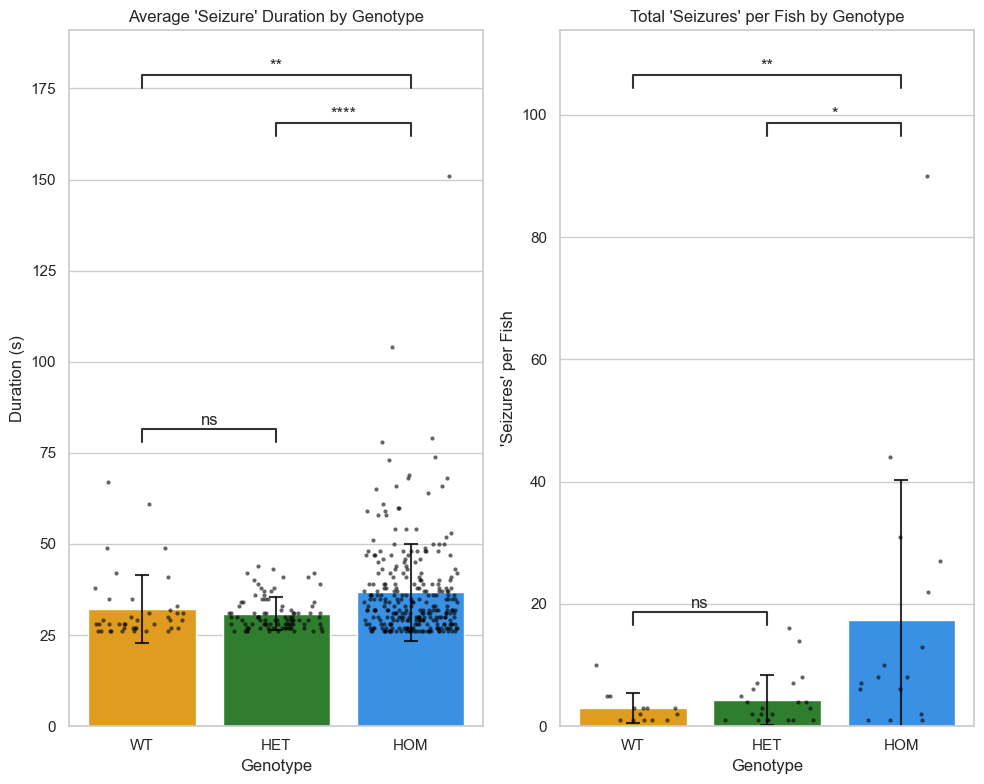

In [272]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, kruskal, mannwhitneyu, f_oneway, ttest_ind
from statannotations.Annotator import Annotator

# Define genotype order and colors
genotype_order = ["WT", "HET", "HOM"]
genotype_colors = {"WT": "#FFA500", "HET": "#228B22", "HOM": "#1E90FF"}

# Ensure genotype is categorical
all_seizure_df['genotype'] = pd.Categorical(all_seizure_df['genotype'], categories=genotype_order, ordered=True)

# Step 1: Count seizures per fish (group by `box`, `well`)
seizure_counts_per_fish = all_seizure_df.groupby(["box", "well"]).size().reset_index(name="seizure_count")

# Step 2: Extract genotype for each fish (keep only first occurrence)
genotype_mapping = all_seizure_df.groupby(["box", "well"])["genotype"].first().reset_index()

# Step 3: Merge genotype back
seizure_counts_per_fish = seizure_counts_per_fish.merge(genotype_mapping, on=["box", "well"], how="left")

# Step 4: Compute summary statistics per genotype
genotype_stats = all_seizure_df.groupby(['genotype'], observed=False).agg(
    duration_mean=('duration', 'mean'),
    duration_std=('duration', 'std'),
    interbout_mean=('IBI', 'mean'),
    interbout_std=('IBI', 'std')
).reset_index()

# Fix: Group seizure_counts_per_fish by genotype, not well
genotype_stats_seizure_count = seizure_counts_per_fish.groupby(['genotype'], observed=False).agg(
    seizure_count_mean=('seizure_count', 'mean'),
    seizure_count_std=('seizure_count', 'std')
).reset_index()

# **Sort for proper ordering**
genotype_stats = genotype_stats.sort_values(by=['genotype'])
genotype_stats_seizure_count = genotype_stats_seizure_count.sort_values(by=['genotype'])

# # **Step 5: Normality Tests**
# normality_results = {}

# for measure, data_source in [("duration", all_seizure_df), ("seizure_count", seizure_counts_per_fish)]:
#     normality_results[measure] = {}
    
#     for genotype in genotype_order:
#         data = data_source.loc[data_source['genotype'] == genotype, measure]
        
#         if len(data) > 3:  # Normality tests require at least 3 values
#             shapiro_p = shapiro(data).pvalue
#             dagostino_p = normaltest(data).pvalue  
            
#             normality_results[measure][genotype] = {
#                 "Shapiro-Wilk p": shapiro_p,
#                 "D’Agostino-Pearson p": dagostino_p
#             }





# **Step 5: Normality Tests**
normality_results = {}

for measure, data_source in [("duration", all_seizure_df), ("seizure_count", seizure_counts_per_fish)]:
    normality_results[measure] = {}
    
    for genotype in genotype_order:
        data = data_source.loc[data_source['genotype'] == genotype, measure]
        n = len(data)
        
        if n > 3:  # Ensure at least 3 values before running normality test
            shapiro_p = shapiro(data).pvalue
            dagostino_p = normaltest(data).pvalue if n >= 20 else None  # Skip `normaltest()` if n < 20
            
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": shapiro_p,
                "D’Agostino-Pearson p": dagostino_p
            }
        else:
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": None,
                "D’Agostino-Pearson p": None
            }






# Function to determine normality
def is_normal(p_values):
    return all(p >= 0.05 for p in p_values.values())

# Check normality
is_duration_normal = is_normal({g: normality_results["duration"][g]["Shapiro-Wilk p"] for g in genotype_order})
is_seizure_count_normal = is_normal({g: normality_results["seizure_count"][g]["Shapiro-Wilk p"] for g in genotype_order})

print(f"Seizure Duration Data Normal? {is_duration_normal}")
print(f"Seizure Count Data Normal? {is_seizure_count_normal}")

# **Step 6: Statistical Tests**
def run_statistical_tests(data, measure, is_normal):
    if is_normal:
        overall_p = f_oneway(*[data.loc[data['genotype'] == g, measure] for g in genotype_order]).pvalue
        test_name = "ANOVA"
        pairwise_tests = {pair: ttest_ind(
            data.loc[data['genotype'] == pair[0], measure],
            data.loc[data['genotype'] == pair[1], measure]
        ).pvalue for pair in pairwise_comparisons}
    else:
        overall_p = kruskal(*[data.loc[data['genotype'] == g, measure] for g in genotype_order]).pvalue
        test_name = "Kruskal-Wallis"
        pairwise_tests = {pair: mannwhitneyu(
            data.loc[data['genotype'] == pair[0], measure],
            data.loc[data['genotype'] == pair[1], measure]
        ).pvalue for pair in pairwise_comparisons}
    
    return test_name, overall_p, pairwise_tests

# Run tests for both measures
duration_test_name, duration_p, duration_pairwise_tests = run_statistical_tests(all_seizure_df, "duration", is_duration_normal)
seizure_count_test_name, seizure_count_p, seizure_count_pairwise_tests = run_statistical_tests(seizure_counts_per_fish, "seizure_count", is_seizure_count_normal)

# Print results
print(f"\nSeizure Duration Test Used: {duration_test_name} | p = {duration_p:.4f}")
for pair, p_val in duration_pairwise_tests.items():
    print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

print(f"\nSeizure Count Test Used: {seizure_count_test_name} | p = {seizure_count_p:.4f}")
for pair, p_val in seizure_count_pairwise_tests.items():
    print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

# **Plotting**
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

def plot_with_points_and_error(ax, data, stats, y_col, y, std_col, y_label, title, p_values):
    sns.barplot(
        data=stats,
        x="genotype",
        y=y_col,
        errorbar=None,
        order=genotype_order, 
        ax=ax,
        hue="genotype",  # Explicitly set hue to match x-variable
        palette=genotype_colors,  
        legend=False  
    )
    sns.stripplot(
        data=data,
        x="genotype",
        y=y,
        dodge=False,
        jitter=0.35,
        order=genotype_order, ax=ax, color='black', alpha=0.6, size=3
    )
    ax.errorbar(
        stats["genotype"], stats[y_col], yerr=stats[std_col],
        fmt='none', ecolor='black', capsize=5, capthick=1.5, alpha=0.8
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Genotype', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_ylim(0, data[y].max() * 1.2)  

    # **Statistical annotations**
    pairs = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]
    annotator = Annotator(ax, pairs, data=data, x="genotype", y=y, order=genotype_order)
    annotator.configure(test=None, text_format="star", loc="inside")
    annotator.set_pvalues_and_annotate([p_values.get(pair, 1) for pair in pairs])

# **Plot 1: Seizure Duration**
plot_with_points_and_error(
    axes[0], all_seizure_df, genotype_stats, 
    "duration_mean", "duration", "duration_std", 
    "Duration (s)", "Average 'Seizure' Duration by Genotype", 
    duration_pairwise_tests
)

# **Plot 2: Seizure Count per Fish**
plot_with_points_and_error(
    axes[1], seizure_counts_per_fish, genotype_stats_seizure_count, 
    "seizure_count_mean", "seizure_count", "seizure_count_std", 
    "'Seizures' per Fish", "Total 'Seizures' per Fish by Genotype", 
    seizure_count_pairwise_tests
)



plt.tight_layout()
# Save figure with transparent background
plt.savefig("250214_14_15_ALDH7A1_20LYS_7dpf.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

In [252]:
from scipy.stats import shapiro, normaltest, kruskal, mannwhitneyu, f_oneway, ttest_ind

# **Normality Tests for Seizure Duration and Seizure Count**
normality_results = {}

for measure, data_source in [("duration", all_seizure_df), ("seizure_count", seizure_counts_per_fish)]:
    normality_results[measure] = {}
    
    for genotype in genotype_order:
        data = data_source.loc[data_source['genotype'] == genotype, measure]
        
        if len(data) > 3:  # Normality tests require at least 3 values
            shapiro_p = shapiro(data).pvalue
            dagostino_p = normaltest(data).pvalue  # Larger sample size
            
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": shapiro_p,
                "D’Agostino-Pearson p": dagostino_p
            }

# **Decide Test Based on Normality**
def is_normal(p_values):
    """Returns True if all normality test p-values are >= 0.05, else False"""
    return all(p >= 0.05 for p in p_values.values())

# **Check normality results**
is_duration_normal = is_normal({g: normality_results["duration"][g]["Shapiro-Wilk p"] for g in genotype_order})
is_seizure_count_normal = is_normal({g: normality_results["seizure_count"][g]["Shapiro-Wilk p"] for g in genotype_order})

print(f"Seizure Duration Data Normal? {is_duration_normal}")
print(f"Seizure Count Data Normal? {is_seizure_count_normal}")

# **Statistical Tests for Seizure Duration**
if is_duration_normal:
    # **Use ANOVA & T-tests**
    duration_p = f_oneway(*[all_seizure_df.loc[all_seizure_df['genotype'] == g, 'duration'] for g in genotype_order]).pvalue
    duration_test_name = "ANOVA"
    duration_pairwise_tests = {pair: ttest_ind(
        all_seizure_df.loc[all_seizure_df['genotype'] == pair[0], 'duration'],
        all_seizure_df.loc[all_seizure_df['genotype'] == pair[1], 'duration']
    ).pvalue for pair in pairwise_comparisons}
else:
    # **Use Kruskal-Wallis & Mann-Whitney U tests**
    duration_p = kruskal(*[all_seizure_df.loc[all_seizure_df['genotype'] == g, 'duration'] for g in genotype_order]).pvalue
    duration_test_name = "Kruskal-Wallis"
    duration_pairwise_tests = {pair: mannwhitneyu(
        all_seizure_df.loc[all_seizure_df['genotype'] == pair[0], 'duration'],
        all_seizure_df.loc[all_seizure_df['genotype'] == pair[1], 'duration']
    ).pvalue for pair in pairwise_comparisons}

# **Statistical Tests for Seizure Count**
if is_seizure_count_normal:
    # **Use ANOVA & T-tests**
    seizure_count_p = f_oneway(*[seizure_counts_per_fish.loc[seizure_counts_per_fish['genotype'] == g, 'seizure_count'] for g in genotype_order]).pvalue
    seizure_count_test_name = "ANOVA"
    seizure_count_pairwise_tests = {pair: ttest_ind(
        seizure_counts_per_fish.loc[seizure_counts_per_fish['genotype'] == pair[0], 'seizure_count'],
        seizure_counts_per_fish.loc[seizure_counts_per_fish['genotype'] == pair[1], 'seizure_count']
    ).pvalue for pair in pairwise_comparisons}
else:
    # **Use Kruskal-Wallis & Mann-Whitney U tests**
    seizure_count_p = kruskal(*[seizure_counts_per_fish.loc[seizure_counts_per_fish['genotype'] == g, 'seizure_count'] for g in genotype_order]).pvalue
    seizure_count_test_name = "Kruskal-Wallis"
    seizure_count_pairwise_tests = {pair: mannwhitneyu(
        seizure_counts_per_fish.loc[seizure_counts_per_fish['genotype'] == pair[0], 'seizure_count'],
        seizure_counts_per_fish.loc[seizure_counts_per_fish['genotype'] == pair[1], 'seizure_count']
    ).pvalue for pair in pairwise_comparisons}

# **Print Results**
print(f"\nSeizure Duration Test Used: {duration_test_name} | p = {duration_p:.4f}")
for pair, p_val in duration_pairwise_tests.items():
    print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

print(f"\nSeizure Count Test Used: {seizure_count_test_name} | p = {seizure_count_p:.4f}")
for pair, p_val in seizure_count_pairwise_tests.items():
    print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

Seizure Duration Data Normal? False
Seizure Count Data Normal? False

Seizure Duration Test Used: Kruskal-Wallis | p = 0.0000
WT vs HET: p = 0.3981
WT vs HOM: p = 0.0011
HET vs HOM: p = 0.0000

Seizure Count Test Used: Kruskal-Wallis | p = 0.0098
WT vs HET: p = 0.4255
WT vs HOM: p = 0.0076
HET vs HOM: p = 0.0137


/opt/homebrew/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/opt/homebrew/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
